In [4]:
import xgi 
from matplotlib import pyplot as plt 
import seaborn as sns
import numpy as np
import os 
import pandas as pd
import pickle
import matplotlib.colors as mcolors
from itertools import product
from scipy.special import binom
from multiprocessing import Pool
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import importlib 
import time
from sod import *
from scipy.interpolate import make_interp_spline, BSpline

plt.style.use('seaborn-v0_8-whitegrid')

m = importlib.import_module(".model", "src")
ll = importlib.import_module(".likelihoods", "src")

def expectation(x):
    
    to_sum = [(i)*j for i,j in enumerate(x)]
      
    return sum(to_sum)
realworld_Hgraphs = ["coauth-dblp", "coauth-mag-geology", "coauth-mag-history",
                     "diseasome", "kaggle-whats-cooking", "ndc-classes", "ndc-substances",
                     "tags-ask-ubuntu", "tags-math-sx" , "tags-stack-overflow", "threads-ask-ubuntu", 
                     "threads-math-sx", "threads-stack-overflow",
                     "congress-bills", "contact-high-school", "contact-primary-school",
                     "email-enron", "email-eu", "hospital-lyon", "hypertext-conference", 
                     "invs13", "invs15",  "malawi-village", "science-gallery", "sfhh-conference"]

In [5]:

# p_gamma = -np.sort(-np.random.exponential(scale=1.0, size=10))
# p_gamma = list(p_gamma / p_gamma.sum())

# print(p_gamma)
# expectation(p_gamma)

eta_list = [0.3, 0.7]
beta_list = []

gamma_list = []


p_beta_1 = [0.90502832570338695,
 0.06852597102421798,
 0.00695958124156278,
 0.00425430441260074,
 0.00513923414596366,
 0.00283459294063147,
 0.00219491091589968,
 0.00355751868523734,
 0.000874040537457661,
 0.0006315203930418162]

p_beta_2 = [0.1181696191800098,
 0.56904908541005407,
 0.28176865827877373,
 0.00922959431020997,
 0.0054277044922998,
 0.00429578036753658,
 0.003301470269982085,
 0.003939276201320242,
 0.00377219213273467,
 0.001046619357079092]


beta_list = [p_beta_1, p_beta_2]

#p_gamma = -np.sort(-np.random.exponential(scale=1.0, size=20))
#p_gamma = list(p_gamma / p_gamma.sum())
p_gamma_1 = [0.26808510691453546,
0.14626545184476625,
 0.10855257597549402,
 0.09914093069058083,
 0.07015466087950174,
 0.05779366818337918,
 0.040675224620690405,
 0.040422307282760035,
 0.03890813877620562,
 0.03606039013263103,
 0.026425470730908805,
 0.02167258582451556,
 0.015359102952971269,
 0.009505581418620465,
 0.0074926102365517385,
 0.00499058812177074,
 0.004907000319279024,
 0.0023934645186247435,
 0.0010124215022168882,
 0.00018271907399612376]

p_gamma_2 = [0.82894182078922285,
 0.06215493012449843,
 0.01192666284335375,
 0.00279141892191949,
 0.00847290102333172,
 0.00886377827593374,
 0.00625207194824165,
 0.00984957246975516,
 0.00301749402598405,
 0.000088960379657,
 0.00366484857364415,
 0.002608868022124676,
 0.009726750682067864,
 0.007883420960180417,
 0.008534809253028417,
 0.008444923410680536,
 0.007057473316011906,
 0.004988774770066662,
 0.003532987383654084,
 0.0011975328266434495]

gamma_list = [p_gamma_1, p_gamma_2]

In [6]:
def return_values(parameters, timesteps):
    
    eta = parameters["eta"]
    beta = parameters["beta"]
    gamma = parameters["gamma"]
    
    mean_edge_size = 1 + (expectation(beta) + expectation(gamma)) / (1-eta)
    param_for_alternatives = mean_edge_size - expectation(beta) - 1
    
    max_order = 10
    min_size= 2
    
    ASSORT = []
    ASSORT_TB = []
    ASSORT_T2 = []
    CLUSTER = []
    SF = []
    FES = []
    
    H = m.GrowingHypergraph()
    H.add_edge((0, 1))
    H.add_edge((2, 3))
    H.add_edge((4, 5, 6, 7))
    H.add_edge((8, 9, 10))
    
    for ii in range(timesteps):
        H.sample_edge(parameters["eta"], parameters["gamma"], parameters["beta"], True)
        if ii%100 == 0:
            start = time.time()
     
            ASSORT.append(xgi.degree_assortativity(H.H, exact = True))
            ASSORT_TB.append(xgi.degree_assortativity(H.H, kind = "top-bottom", exact = True))
            ASSORT_T2.append(xgi.degree_assortativity(H.H, kind = "top-2", exact = True))
            CLUSTER.append(np.mean(list(xgi.clustering_coefficient(H.H).values())))
            
            G = xgi.subhypergraph(H.H, edges=H.H.edges.filterby("order", max_order, "leq")).copy()
        
            SF.append(edit_simpliciality(G, min_size=min_size))
            FES.append(face_edit_simpliciality(G, min_size=min_size))
            #print(time.time()-start)
 
    ASSORT_ER = []
    ASSORT_TB_ER = []
    ASSORT_T2_ER = []
    CLUSTER_ER = []
    SF_ER = []
    FES_ER = []
    
    H = m.GrowingHypergraph()
    H.add_edge((0, 1))
    H.add_edge((2, 3))
    H.add_edge((4, 5, 6, 7))
    H.add_edge((8, 9, 10))
    
    for ii in range(timesteps):
        
        H.sample_edge_alternative("ER", param_for_alternatives, expectation(beta))
        
        if ii%100 == 0:
            start = time.time()

            ASSORT_ER.append(xgi.degree_assortativity(H.H, exact = True))
            ASSORT_TB_ER.append(xgi.degree_assortativity(H.H, kind = "top-bottom", exact = True))
            ASSORT_T2_ER.append(xgi.degree_assortativity(H.H, kind = "top-2", exact = True))
            CLUSTER_ER.append(np.mean(list(xgi.clustering_coefficient(H.H).values())))

            G = xgi.subhypergraph(H.H, edges=H.H.edges.filterby("order", max_order, "leq")).copy()
        
            SF_ER.append(edit_simpliciality(G, min_size=min_size))
            FES_ER.append(face_edit_simpliciality(G, min_size=min_size))
    
    d = {}
    d["assort"] = ASSORT
    d["assort_tb"] = ASSORT_TB
    d["assort_t2"] = ASSORT_T2
    d["cluster"] = CLUSTER
    d["SF"] = SF
    d["FES"] = FES
    
    d["assort_er"] = ASSORT_ER
    d["cluster_er"] = CLUSTER_ER
    d["assort_tb_er"] = ASSORT_TB_ER
    d["assort_t2_er"] = ASSORT_T2_ER
    d["SF_er"] = SF_ER
    d["FES_er"] = FES_ER
    
    save_name = "eta_" + str(eta) + "_beta_" + str(round(expectation(beta),2))  + "_gamma_" + str(round(expectation(gamma),2)) 
    
    with open('property_results/res_{}.pkl'.format(save_name), 'wb') as fp:
        pickle.dump(d, fp, protocol=pickle.HIGHEST_PROTOCOL)  
    
    return 

Assortativity_Top2
eta_0.3_beta_0.18_gamma_3.52
eta_0.3_beta_1.29_gamma_3.52
eta_0.7_beta_0.18_gamma_3.52
eta_0.7_beta_1.29_gamma_3.52
Clustering Coefficient
eta_0.3_beta_0.18_gamma_3.52
eta_0.3_beta_1.29_gamma_3.52
eta_0.7_beta_0.18_gamma_3.52
eta_0.7_beta_1.29_gamma_3.52
Edit Simpliciality
eta_0.3_beta_0.18_gamma_3.52
eta_0.3_beta_1.29_gamma_3.52
eta_0.7_beta_0.18_gamma_3.52
eta_0.7_beta_1.29_gamma_3.52
Face Edit Simpliciality
eta_0.3_beta_0.18_gamma_3.52
eta_0.3_beta_1.29_gamma_3.52
eta_0.7_beta_0.18_gamma_3.52
eta_0.7_beta_1.29_gamma_3.52


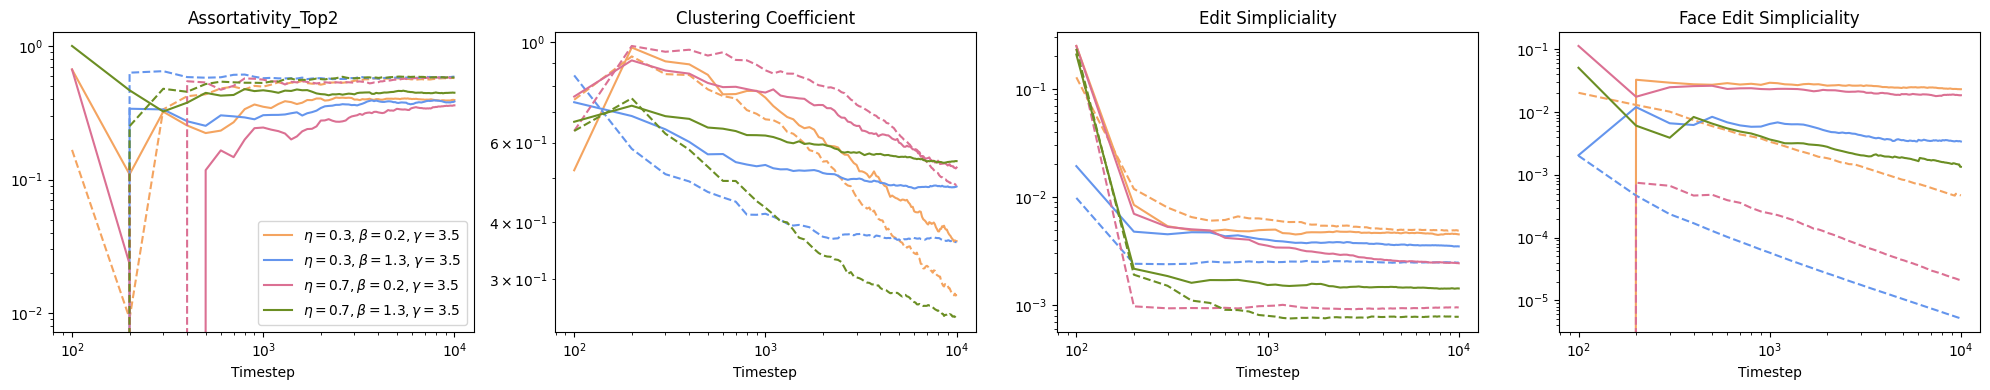

In [9]:
# properties = ["Assortativity", "Assortativity_TopBottom", "Assortativity_Top2", 
#               "Clustering Coefficient", "Edit Simpliciality", "Face Edit Simpliciality"]
# idx = ["assort", "assort_tb", "assort_t2", "cluster", "SF", "FES"]
# idx_er = ["assort_er", "assort_tb_er", "assort_t2_er", "cluster_er", "SF_er", "FES_er"]

properties = [ "Assortativity_Top2", "Clustering Coefficient", "Edit Simpliciality", "Face Edit Simpliciality"]
idx = ["assort_t2", "cluster", "SF", "FES"]
idx_er = ["assort_t2_er", "cluster_er", "SF_er", "FES_er"]

fig, ax = plt.subplots(1, 4, figsize = (20, 4), sharey= False)
ax = ax.flatten()
inferno = ["sandybrown", "cornflowerblue", "palevioletred", "olivedrab",
          "sandybrown", "cornflowerblue", "palevioletred", "olivedrab"]                                   
                                        
timeline = [x*100 for x in range(1,101)]


for i in range(4):
    property_ = properties[i]
    print(property_)
    ax[i].loglog()
    ax[i].set(title = f"{property_}")
    ax[i].set(xlabel = "Timestep")
    
    count = 0
    for eta in eta_list:
        for beta in beta_list:
            for gamma in gamma_list[0:1]:

                save_name = "eta_" + str(eta) + "_beta_" + str(round(expectation(beta),2)) + "_gamma_" + str(round(expectation(gamma),2)) 
                print(save_name)
                lab = r"$\eta = $" + str(eta) + r"$, \beta = $" + str(round(expectation(beta), 1)) + r"$, \gamma = $" + str(round(expectation(gamma),1)) 
                #lab_er =  "ER"+ r"$\eta:$" + str(eta) + r"$ \beta:$" + str(beta) + r"$ \gamma:$" + str(round(expectation(gamma),2)) 

                with open('property_results/res_{}.pkl'.format(save_name), 'rb') as fp:
                    pars = pickle.load(fp)
                
                #print(pars)
                
                #spl = make_interp_spline(timeline, pars[idx[i]], k=99)
                #spl_er = make_interp_spline(timeline, pars[idx_er[i]], k= 99)
                
                ax[i].plot(timeline, pars[idx[i]], label = lab, color = inferno[count])
                ax[i].plot(timeline, pars[idx_er[i]], color = inferno[count], linestyle='dashed')
                count = count + 1
 
ax[0].legend() #bbox_to_anchor=(-0.1, 0.7)
#ax[0].set(ylabel = "Edge intersection rate (normalized)")
plt.tight_layout()
plt.savefig("figures/four_property_plot.pdf",bbox_inches='tight')

In [12]:
H = xgi.load_xgi_data("email-enron")
print(xgi.degree_assortativity(H))
print(np.mean(list(xgi.clustering_coefficient(H).values())))
max_order = 10
min_size = 2 
G = xgi.subhypergraph(H, edges=H.edges.filterby("order", max_order, "leq")).copy()

print(simplicial_fraction(G, min_size=min_size))
print(face_edit_simpliciality(G, min_size=min_size))

0.4659552796397268
0.6358900106796481


C:\Users\hexie\.conda\envs\Hgraph\lib\site-packages\xgi\linalg\hypergraph_matrix.py:185: UserWarning: Forming the adjacency matrix can be expensive when there are isolated nodes!
  warn(


0.2629032258064516
0.5260287406978799
